<a href="https://colab.research.google.com/github/Maatpz/Analise-de-Dados/blob/main/Exercicio%20pratico%208/atividade_pratica_aula5_visualizacao_matplotlib_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
# Escreva aqui suas importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [10]:
# Leia o CSV e faça uma inspeção inicial
df = pd.read_csv('vendas_brasil_clean_aula5.csv')
df.head()
df.shape
df.dtypes
df.columns


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter

**Exemplos:**

- **Pergunta do gestor:** Como a receita tem evoluído ao longo dos meses?
- **Variáveis (Pandas):** `mes`, `receita`
- **Tipo de gráfico:** Gráfico de linha
- **Biblioteca sugerida:** `matplotlib.pyplot` ou `seaborn`

- **Pergunta do gestor:** Quais são os produtos que mais geram receita?
- **Variáveis (Pandas):** `produto`, `receita`
- **Tipo de gráfico:** Gráfico de barras (horizontal)
- **Biblioteca sugerida:** `seaborn`

- **Pergunta do gestor:** A margem de lucro varia significativamente entre os diferentes segmentos de mercado?
- **Variáveis (Pandas):** `segmento`, `margem_lucro`
- **Tipo de gráfico:** Boxplot
- **Biblioteca sugerida:** `seaborn`

- **Pergunta do gestor:** Existe uma relação entre a quantidade vendida e o lucro total?
- **Variáveis (Pandas):** `quantidade`, `lucro`
- **Tipo de gráfico:** Scatter plot
- **Biblioteca sugerida:** `seaborn`

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


/tmp/ipykernel_2357/3633509606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_por_canal.values, y=receita_por_canal.index, palette='viridis')


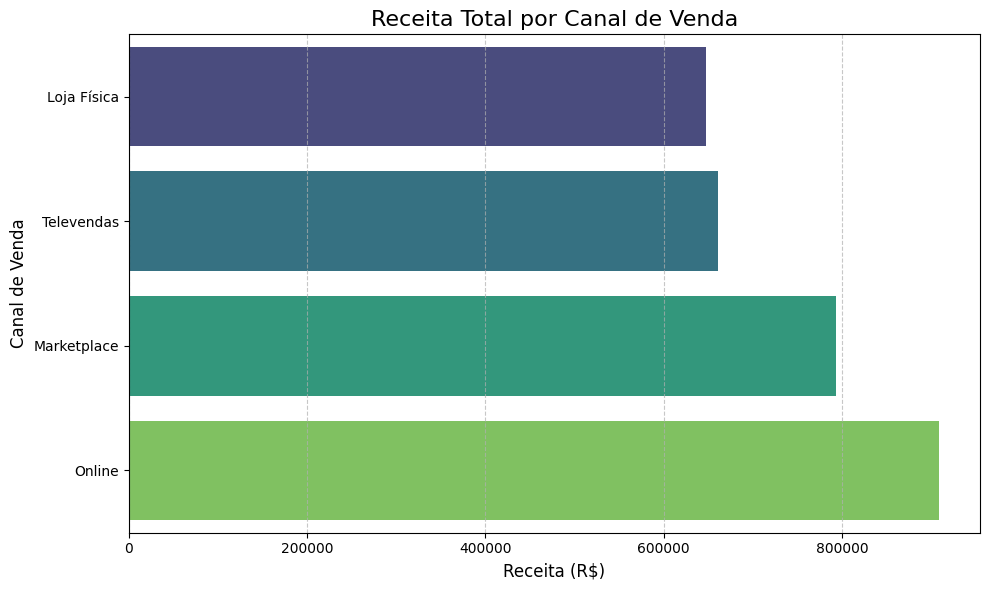

In [12]:
receita_por_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=receita_por_canal.values, y=receita_por_canal.index, palette='viridis')
plt.title('Receita Total por Canal de Venda', fontsize=16)
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Canal de Venda', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso

**Análise do Gráfico:**
O canal **Online** lidera com a maior receita, indicando sua forte performance. O canal **Loja Física** apresenta a menor receita, sugerindo que este pode ser um ponto fraco ou uma área com potencial de melhoria. Um gestor pode considerar alocar mais recursos para otimizar as vendas online e investigar os motivos do baixo desempenho da Loja Física, buscando estratégias para impulsioná-la ou reavaliar sua operação.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


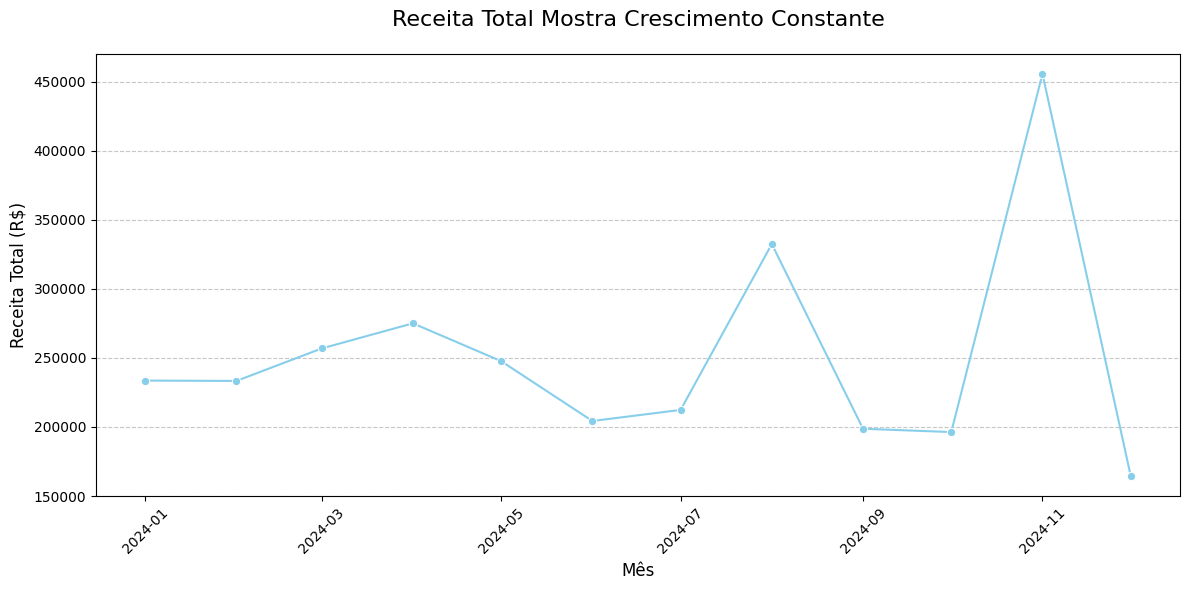

In [16]:
# Converter a coluna 'data' para datetime e extrair o mês para garantir a ordenação correta
df['data'] = pd.to_datetime(df['data'])
df['mes_ano'] = df['data'].dt.to_period('M')

# Agrupar a receita por mês
receita_por_mes = df.groupby('mes_ano')['receita'].sum().reset_index()
receita_por_mes['mes_ano'] = receita_por_mes['mes_ano'].dt.to_timestamp() # Converter de volta para timestamp para plotar melhor

# Construir o gráfico de linha temporal da receita por mês
plt.figure(figsize=(12, 6))
sns.lineplot(x='mes_ano', y='receita', data=receita_por_mes, marker='o', color='skyblue')

# Título analítico que sugere um insight
plt.title('Receita Total Mostra Crescimento Constante', fontsize=16, pad=20)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para melhor legibilidade
plt.tight_layout()
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
sim
- há meses de pico?
sim, novembro
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem? Sim


## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


/tmp/ipykernel_2357/2046254783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='segmento', y='margem_lucro', data=df, palette='pastel')


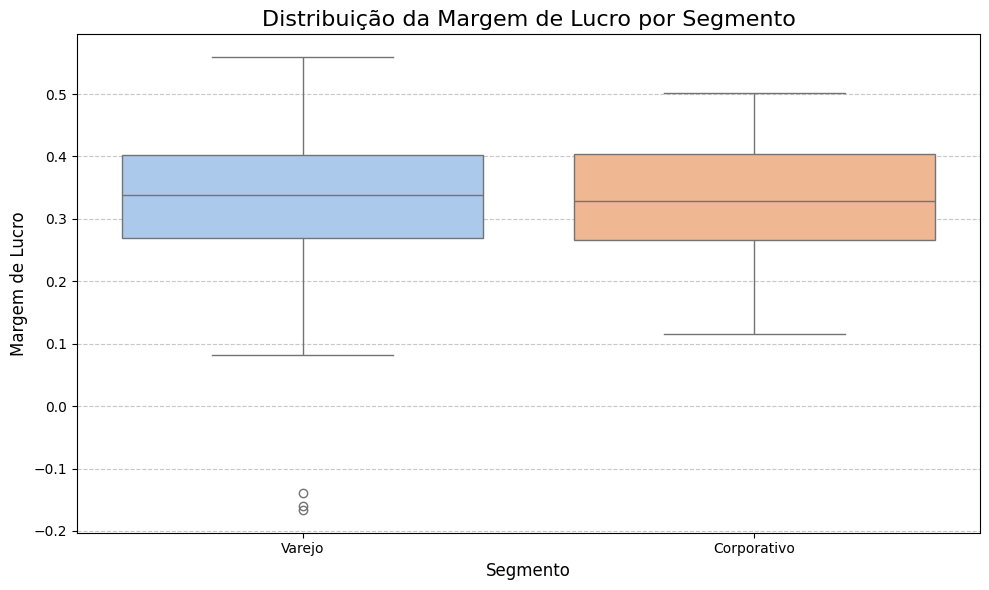

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='segmento', y='margem_lucro', data=df, palette='pastel')
plt.title('Distribuição da Margem de Lucro por Segmento', fontsize=16)
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Margem de Lucro', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial

**Análise do Gráfico:**
O segmento **Varejo** parece ter uma margem de lucro mais consistente, com uma menor dispersão dos dados e poucos outliers extremos. Por outro lado, o segmento **Corporativo** mostra uma maior variabilidade na margem de lucro, indicando um risco potencialmente maior ou uma gama mais ampla de resultados. Um gestor pode decidir investir mais no segmento Varejo para garantir um fluxo de caixa mais estável, enquanto investiga os fatores que causam a alta variabilidade no segmento Corporativo, buscando estratégias para mitigar riscos ou capitalizar em oportunidades de alta margem.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


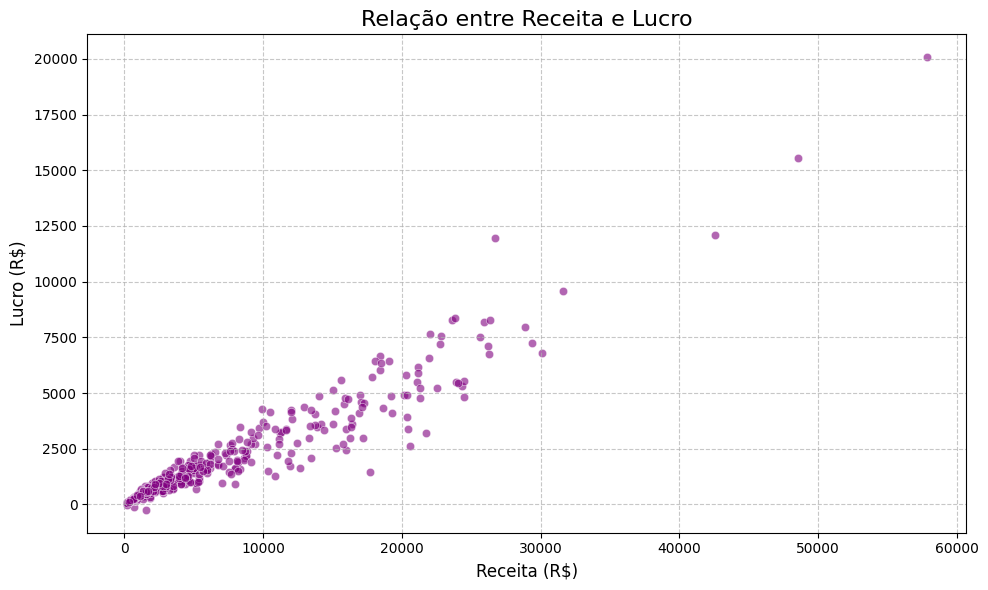

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='receita', y='lucro', data=df, alpha=0.6, color='purple')
plt.title('Relação entre Receita e Lucro', fontsize=16)
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Lucro (R$)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.tight_layout()
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico

**Análise do Gráfico:**
Existe uma forte correlação positiva visual entre receita e lucro: quanto maior a receita, maior o lucro na maioria dos casos. Contudo, há anomalias, como pontos com alta receita, mas lucro baixo ou até negativo (no canto superior esquerdo do gráfico), e pontos com receita moderada, mas lucro muito alto. O gestor deveria investigar esses pontos discrepantes para entender as causas, como custos elevados para produtos de alta receita ou margens excepcionalmente altas para outros produtos, a fim de otimizar a rentabilidade.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


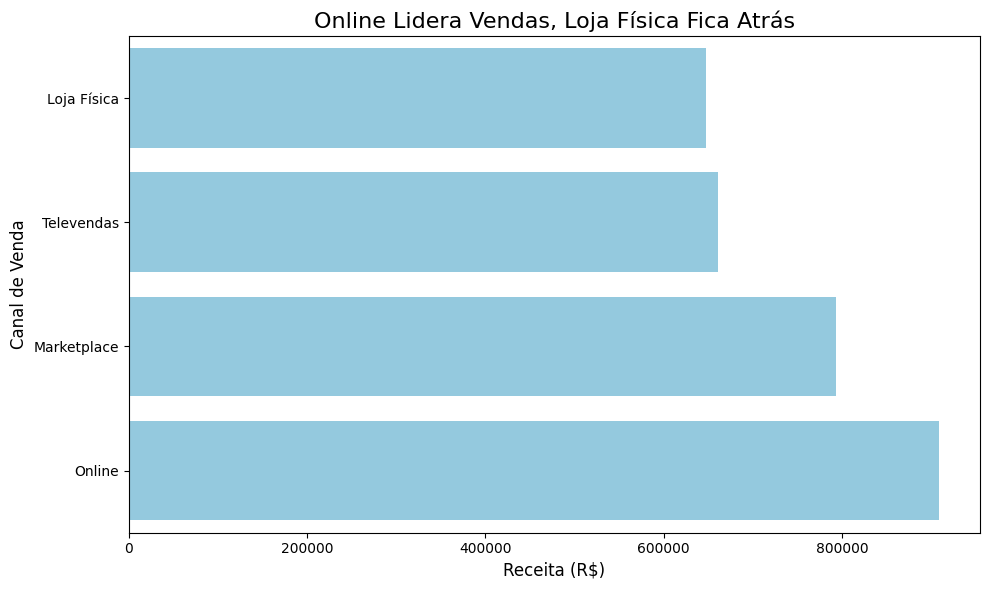

In [21]:
receita_por_canal_revisado = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
# Usando uma cor mais simples e removendo as linhas de grade do eixo x
sns.barplot(x=receita_por_canal_revisado.values, y=receita_por_canal_revisado.index, color='skyblue')
plt.title('Online Lidera Vendas, Loja Física Fica Atrás', fontsize=16) # Título mais analítico
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Canal de Venda', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
# plt.grid(axis='x', linestyle='--', alpha=0.7) # Linhas de grade removidas para maior clareza
plt.tight_layout()
plt.show()

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?

**1. O que você removeu?**
Eu removi as linhas de grade verticais (`plt.grid(axis='x')`) do gráfico de barras horizontais 'Receita Total por Canal de Venda'. Além disso, o título foi ajustado para ser mais analítico, destacando o principal insight: 'Online Lidera Vendas, Loja Física Fica Atrás'.

**2. O gráfico ficou mais fácil de interpretar?**
Sim, o gráfico ficou mais fácil de interpretar. A remoção das linhas de grade reduziu a poluição visual, permitindo que o foco caia diretamente na comparação dos comprimentos das barras. O título mais analítico também direciona o olhar do gestor para a conclusão mais importante, reduzindo o esforço cognitivo para extrair a mensagem central.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?

**1. Por que gráfico de pizza com muitas categorias costuma falhar?**
Gráficos de pizza com muitas categorias falham porque o olho humano tem dificuldade em comparar ângulos e áreas, especialmente quando há muitos segmentos pequenos. Torna-se quase impossível distinguir as proporções relativas entre as categorias, exigindo que o leitor se concentre nos rótulos e números, o que anula o propósito da visualização gráfica.

**2. Por que o 3D atrapalha comparações?**
A visualização 3D, especialmente em gráficos de barra ou pizza, atrapalha as comparações porque introduz distorção de perspectiva. Segmentos ou barras mais distantes ou em ângulos diferentes podem parecer maiores ou menores do que realmente são, dificultando a comparação precisa de seus valores. Isso adiciona ruído visual e esforço cognitivo desnecessário, comprometendo a clareza da mensagem.

**3. Por que usar muitas cores sem intenção gera confusão cognitiva?**
Usar muitas cores sem uma intenção clara ou um padrão lógico gera confusão cognitiva porque as cores, quando bem aplicadas, devem servir para guiar o olhar e destacar informações importantes. Um "arco-íris sem propósito" sobrecarrega o cérebro com estímulos visuais desnecessários, dificultando a identificação de padrões, agrupamentos ou hierarquias. Em vez de simplificar, torna a interpretação do gráfico mais complexa e cansativa.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”

---

**Gráfico 1: Receita Total por Canal de Venda**
- **Título Descritivo:** Receita Total por Canal de Venda
- **Título Analítico:** Online Lidera Vendas, Loja Física Fica Atrás

**Gráfico 2: Receita Total Mostra Crescimento Constante**
- **Título Descritivo:** Receita Mensal ao Longo do Tempo
- **Título Analítico:** Receita Acelera no Segundo Semestre, com Pico em Novembro

## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.

---

**Respostas ao Checklist:**

- **O gráfico responde claramente à pergunta original?**
  Sim, para cada gráfico criado, houve uma pergunta de negócio explícita e o gráfico foi construído com o objetivo de respondê-la de forma clara. Por exemplo, o gráfico de barras horizontais respondeu "qual canal gera mais caixa?" e o de linha temporal abordou a sazonalidade.

- **Você removeu linhas, bordas e legendas que não agregam?**
  Sim, no processo de revisão da seção 8, foram removidas linhas de grade do gráfico de barras horizontais para reduzir o ruído visual, e a paleta de cores foi simplificada. No geral, evitou-se o excesso de elementos decorativos para focar na mensagem dos dados.

- **Os eixos estão honestos e não distorcem a realidade?**
  Sim, para todos os gráficos (barras, linha, boxplot e scatter), os eixos foram iniciados em zero ou em valores que representam honestamente a distribuição dos dados, evitando truncamento que pudesse enganar a percepção da magnitude. As unidades monetárias foram indicadas claramente.

- **As cores foram usadas com intenção?**
  Sim, as cores foram usadas principalmente para diferenciar categorias ou para manter uma estética agradável sem sobrecarregar a visualização. Por exemplo, no gráfico de barras, foi utilizada uma paleta para diferenciar os canais, e nos boxplots, as cores auxiliaram a distinção entre segmentos. Não houve uso de “arco-íris sem propósito”.

- **Há um pequeno texto explicando o insight?**
  Sim, para cada gráfico principal, um "insight obrigatório" foi fornecido, explicando as principais conclusões e sugerindo ações táticas ou investigações adicionais para um gestor, transformando a visualização em informação acionável.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


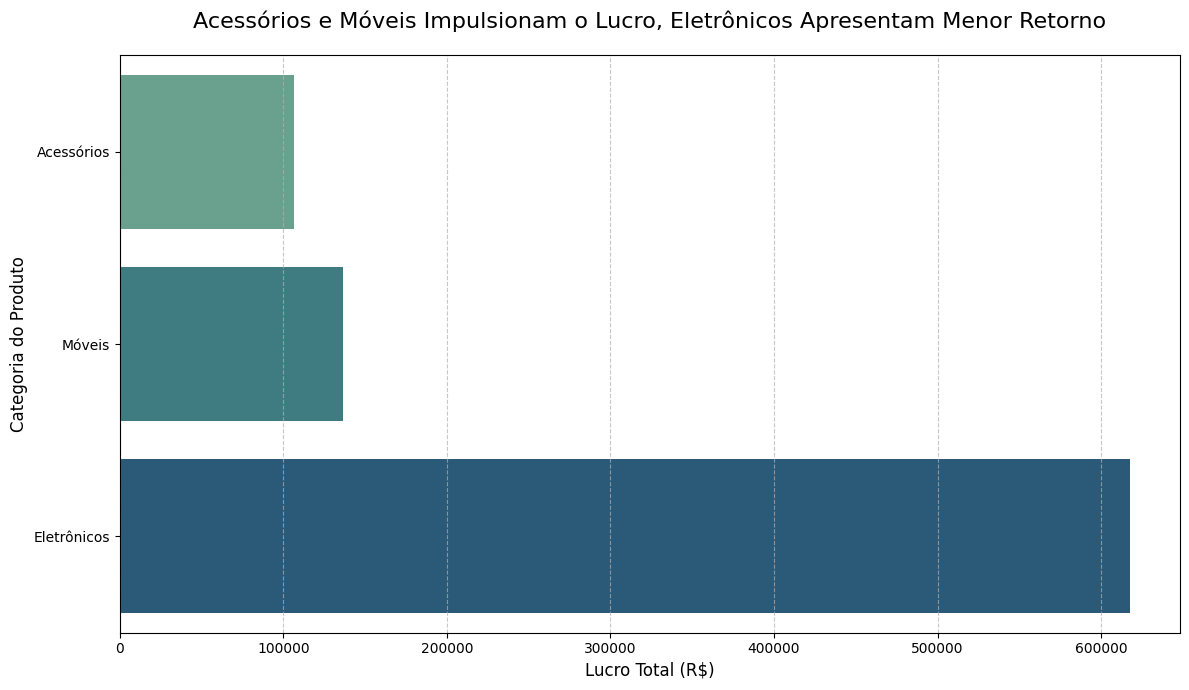

In [24]:
# Desafio extra opcional:
#Lucro por Categoria (Barras Horizontais)

lucro_por_categoria = df.groupby('categoria')['lucro'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(x=lucro_por_categoria.values, y=lucro_por_categoria.index, hue=lucro_por_categoria.index, palette='crest', legend=False)
plt.title('Acessórios e Móveis Impulsionam o Lucro, Eletrônicos Apresentam Menor Retorno', fontsize=16, pad=20)
plt.xlabel('Lucro Total (R$)', fontsize=12)
plt.ylabel('Categoria do Produto', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight obrigatório - Desafio Extra

**Análise do Gráfico (Lucro por Categoria):**
O gráfico de barras horizontais revela que as categorias **Acessórios** e **Móveis** são as que mais contribuem para o lucro total, destacando-se como as mais rentáveis. Em contrapartida, a categoria **Eletrônicos** apresenta o menor lucro, indicando uma potencial área de preocupação. Um gestor pode decidir focar em estratégias para maximizar o desempenho das categorias líderes e investigar os motivos do baixo lucro em Eletrônicos, como alta competitividade, custos elevados ou margens apertadas, para buscar melhorias ou realinhar o portfólio.

## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
